# Аналіз другого BehaviourSpace-експерименту

Notebook призначений для аналізу експерименту з тривалістю програми винагород.

Основні задачі:

- перевірити повноту та збалансованість факторного дизайну;
- оцінити вплив `reward-duration`;
- дослідити взаємодії тривалості програми з `crowding-out-rate`, `high-reward` і `habit-learning-rate`;
- порівняти короткострокову ефективність та стійкість поведінки після скасування винагороди;
- виконати factorial ANOVA;
- побудувати Random Forest і permutation importance;
- знайти сценарії з найкращою persistence та найсильнішим crowding-out;
- експортувати таблиці й рисунки.

## Підготовка середовища

```bash
python -m pip install pandas numpy matplotlib scikit-learn statsmodels
```

У notebook використовується `n_jobs=1`, щоб уникнути проблем `joblib/loky` на macOS із Python 3.13.

In [36]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

OUTPUT_DIR = Path("analysis_output_second_experiment")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /Users/igor/projects/phd/reward-habits-model/analysis_output_second_experiment


## Налаштування


In [37]:
CSV_PATH = Path("./experiments/3/reward-habits-reward-duration-experiment-table.csv")

PARAMETERS = [
    "reward-duration",
    "high-reward",
    "crowding-out-rate",
    "habit-learning-rate",
]

FIXED_PARAMETERS = [
    "low-reward",
]

PRIMARY_TARGET = "high-reward-crowding-out-effect"
SECONDARY_TARGET = "low-reward-persistence-effect"

REWARD_RATES = [
    'choice-rate "control" "reward"',
    'choice-rate "low-salience" "reward"',
    'choice-rate "high-salience" "reward"',
]

WITHDRAWAL_RATES = [
    'choice-rate "control" "withdrawal"',
    'choice-rate "low-salience" "withdrawal"',
    'choice-rate "high-salience" "withdrawal"',
]

MOTIVATION_METRICS = [
    'mean-intrinsic-motivation "control"',
    'mean-intrinsic-motivation "low-salience"',
    'mean-intrinsic-motivation "high-salience"',
]

HABIT_METRICS = [
    'mean-habit "control"',
    'mean-habit "low-salience"',
    'mean-habit "high-salience"',
]

OPTIONAL_METRICS = [
    "high-reward-withdrawal-drop",
    "low-reward-withdrawal-drop",
    "high-reward-retention-ratio",
    "low-reward-retention-ratio",
]

## Завантаження даних

BehaviourSpace Table output читається напряму з пропуском перших шести службових рядків.

In [38]:
df = pd.read_csv(CSV_PATH, skiprows=6)
df.columns = df.columns.astype(str).str.strip()

print("Shape:", df.shape)
print("\nColumns:")
for column in df.columns:
    print("-", column)

df.head()

Shape: (2700, 27)

Columns:
- [run number]
- reward-duration
- high-reward
- crowding-out-rate
- habit-learning-rate
- low-reward
- [step]
- high-reward-crowding-out-effect
- low-reward-persistence-effect
- choice-rate "control" "withdrawal"
- choice-rate "low-salience" "withdrawal"
- choice-rate "high-salience" "withdrawal"
- mean-intrinsic-motivation "control"
- mean-intrinsic-motivation "low-salience"
- mean-intrinsic-motivation "high-salience"
- mean-habit "control"
- mean-habit "low-salience"
- mean-habit "high-salience"
- choice-rate "control" "reward"
- choice-rate "low-salience" "reward"
- choice-rate "high-salience" "reward"
- choice-rate "high-salience" "reward" - choice-rate "high-salience" "withdrawal"
- choice-rate "high-salience" "reward" - choice-rate "high-salience" "withdrawal".1
- high-reward-withdrawal-drop
- low-reward-withdrawal-drop
- high-reward-retention-ratio
- low-reward-retention-ratio


,[run number],reward-duration,high-reward,crowding-out-rate,habit-learning-rate,low-reward,[step],high-reward-crowding-out-effect,low-reward-persistence-effect,"choice-rate ""control"" ""withdrawal""","choice-rate ""low-salience"" ""withdrawal""","choice-rate ""high-salience"" ""withdrawal""","mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience""","choice-rate ""control"" ""reward""","choice-rate ""low-salience"" ""reward""","choice-rate ""high-salience"" ""reward""","choice-rate ""high-salience"" ""reward"" - choice-rate ""high-salience"" ""withdrawal""","choice-rate ""high-salience"" ""reward"" - choice-rate ""high-salience"" ""withdrawal"".1",high-reward-withdrawal-drop,low-reward-withdrawal-drop,high-reward-retention-ratio,low-reward-retention-ratio
0,4,15,0.7,0.01,0.005,0.3,105,0.033754,0.040311,0.540120,0.580430,0.573874,0.484976,0.513446,0.491487,0.141672,0.200844,0.222453,0.552695,0.703904,0.832232,0.258358,0.258358,0.258358,0.123473,0.689560,0.824588
1,2,15,0.7,0.01,0.005,0.3,105,0.032108,0.023849,0.558483,0.582332,0.590591,0.495984,0.514166,0.501534,0.173452,0.212132,0.240897,0.564271,0.714915,0.843443,0.252853,0.252853,0.252853,0.132583,0.700214,0.814548
2,5,15,0.7,0.01,0.005,0.3,105,0.045677,0.035517,0.543663,0.579179,0.589339,0.491116,0.515647,0.498763,0.151846,0.206222,0.235684,0.547305,0.712112,0.844044,0.254705,0.254705,0.254705,0.132933,0.698233,0.813326
3,3,15,0.7,0.01,0.005,0.3,105,0.029209,0.026907,0.559930,0.586837,0.589139,0.504971,0.520977,0.496394,0.171503,0.206321,0.237107,0.571457,0.712112,0.839439,0.250300,0.250300,0.250300,0.125275,0.701824,0.824079
4,1,15,0.7,0.01,0.005,0.3,105,0.015188,0.031204,0.557685,0.588889,0.572873,0.502077,0.517710,0.488361,0.160775,0.205225,0.226028,0.565669,0.703103,0.824825,0.251952,0.251952,0.251952,0.114214,0.694539,0.837557


## Перевірка структури

In [39]:
required_columns = (
    ["[run number]"]
    + PARAMETERS
    + FIXED_PARAMETERS
    + [PRIMARY_TARGET, SECONDARY_TARGET]
    + REWARD_RATES
    + WITHDRAWAL_RATES
    + MOTIVATION_METRICS
    + HABIT_METRICS
)

missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    print("Відсутні очікувані колонки:")
    for column in missing_columns:
        print("-", column)
else:
    print("Усі обов'язкові колонки присутні.")

available_optional_metrics = [
    column for column in OPTIONAL_METRICS if column in df.columns
]

print("\nOptional metrics found:")
for column in available_optional_metrics:
    print("-", column)

Усі обов'язкові колонки присутні.

Optional metrics found:
- high-reward-withdrawal-drop
- low-reward-withdrawal-drop
- high-reward-retention-ratio
- low-reward-retention-ratio


## Очищення даних

In [40]:
analysis_columns = (
    PARAMETERS
    + FIXED_PARAMETERS
    + [PRIMARY_TARGET, SECONDARY_TARGET]
    + REWARD_RATES
    + WITHDRAWAL_RATES
    + MOTIVATION_METRICS
    + HABIT_METRICS
    + available_optional_metrics
)

clean_df = df.copy()

for column in analysis_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

before_rows = len(clean_df)

clean_df = clean_df.dropna(
    subset=PARAMETERS + [PRIMARY_TARGET, SECONDARY_TARGET]
).copy()

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", len(clean_df))
print("Removed rows:", before_rows - len(clean_df))

Rows before cleaning: 2700
Rows after cleaning: 2700
Removed rows: 0


## Перевірка факторного дизайну

In [41]:
design_counts = (
    clean_df.groupby(PARAMETERS, dropna=False)
    .size()
    .reset_index(name="repetitions")
)

print("Parameter combinations:", len(design_counts))
print("Minimum repetitions:", design_counts["repetitions"].min())
print("Maximum repetitions:", design_counts["repetitions"].max())

if design_counts["repetitions"].nunique() == 1:
    print("Дизайн збалансований.")
else:
    print("Увага: кількість повторень відрізняється між сценаріями.")

design_counts.head()

Parameter combinations: 135
Minimum repetitions: 20
Maximum repetitions: 20
Дизайн збалансований.


,reward-duration,high-reward,crowding-out-rate,habit-learning-rate,repetitions
0,15,0.7,0.01,0.005,20
1,15,0.7,0.01,0.020,20
2,15,0.7,0.01,0.050,20
3,15,0.7,0.03,0.005,20
4,15,0.7,0.03,0.020,20


In [42]:
design_counts["repetitions"].value_counts().sort_index()

repetitions
20    135
Name: count, dtype: int64

## Перевірка фіксованих параметрів

In [43]:
for parameter in FIXED_PARAMETERS:
    print(parameter, sorted(clean_df[parameter].dropna().unique()))

low-reward [np.float64(0.3)]


## Описова статистика

In [44]:
summary_metrics = (
    [PRIMARY_TARGET, SECONDARY_TARGET]
    + REWARD_RATES
    + WITHDRAWAL_RATES
    + MOTIVATION_METRICS
    + HABIT_METRICS
    + available_optional_metrics
)

clean_df[summary_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
high-reward-crowding-out-effect,2700.0,-0.048903,0.082130,-0.312140,-0.090878,-0.029401,0.007915,0.137966
low-reward-persistence-effect,2700.0,0.051181,0.034875,-0.014791,0.025030,0.043276,0.070090,0.163394
"choice-rate ""control"" ""reward""",2700.0,0.674883,0.090764,0.533184,0.563648,0.692415,0.765993,0.802221
"choice-rate ""low-salience"" ""reward""",2700.0,0.806714,0.067180,0.674474,0.737907,0.829104,0.864302,0.900025
"choice-rate ""high-salience"" ""reward""",2700.0,0.908604,0.036245,0.819419,0.885085,0.918769,0.936136,0.964064
"choice-rate ""control"" ""withdrawal""",2700.0,0.695815,0.102671,0.523703,0.561577,0.739820,0.790095,0.811627
"choice-rate ""low-salience"" ""withdrawal""",2700.0,0.746995,0.091314,0.556507,0.665553,0.794469,0.823423,0.854905
"choice-rate ""high-salience"" ""withdrawal""",2700.0,0.646912,0.108253,0.341742,0.567217,0.666767,0.739502,0.807708
"mean-intrinsic-motivation ""control""",2700.0,0.499897,0.007965,0.469749,0.494590,0.499856,0.505396,0.524470
"mean-intrinsic-motivation ""low-salience""",2700.0,0.546661,0.029530,0.489854,0.520559,0.544796,0.571757,0.613880


## Частота crowding-out та позитивної persistence

In [45]:
crowding_share = (clean_df[PRIMARY_TARGET] < 0).mean()
positive_low_persistence_share = (clean_df[SECONDARY_TARGET] > 0).mean()

print(f"Частка запусків із high-reward crowding-out: {crowding_share:.1%}")
print(f"Частка запусків із позитивним low-reward persistence: {positive_low_persistence_share:.1%}")

Частка запусків із high-reward crowding-out: 69.8%
Частка запусків із позитивним low-reward persistence: 99.0%


## Розподіл основних KPI

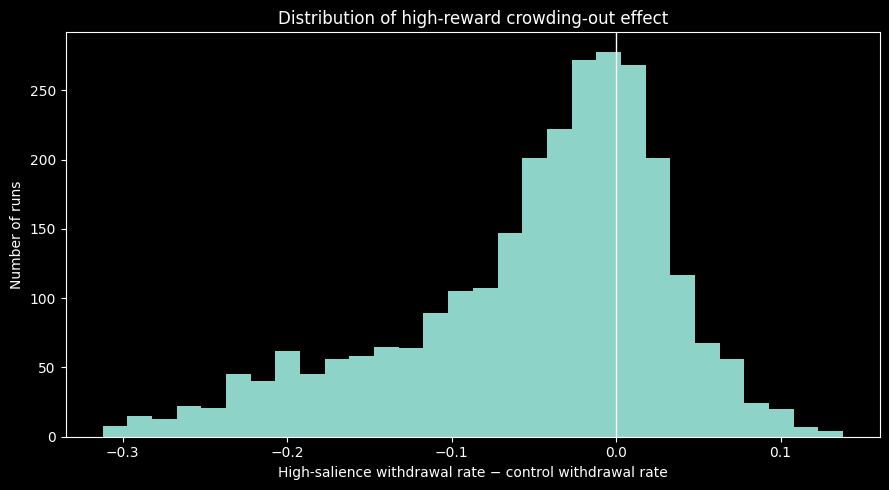

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(clean_df[PRIMARY_TARGET], bins=30)
ax.axvline(0, linewidth=1)
ax.set_title("Distribution of high-reward crowding-out effect")
ax.set_xlabel("High-salience withdrawal rate − control withdrawal rate")
ax.set_ylabel("Number of runs")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "distribution_high_reward_crowding_out.png", dpi=200)
plt.show()

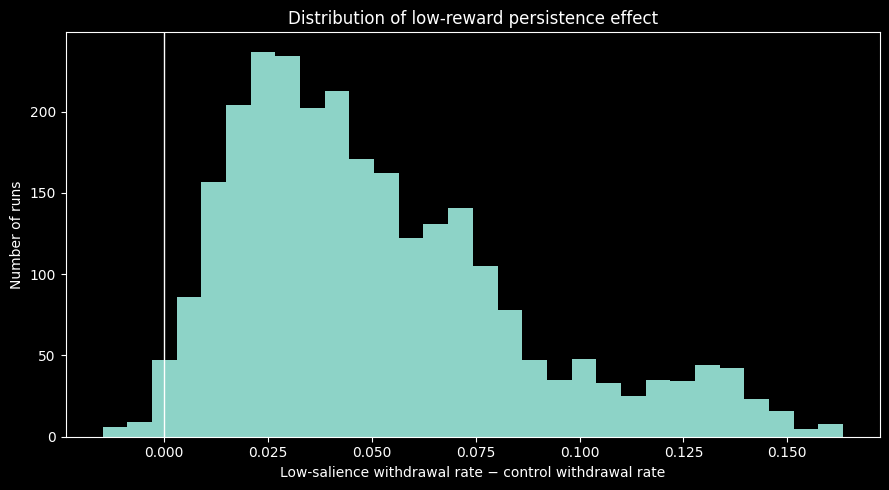

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(clean_df[SECONDARY_TARGET], bins=30)
ax.axvline(0, linewidth=1)
ax.set_title("Distribution of low-reward persistence effect")
ax.set_xlabel("Low-salience withdrawal rate − control withdrawal rate")
ax.set_ylabel("Number of runs")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "distribution_low_reward_persistence.png", dpi=200)
plt.show()

## Головний ефект тривалості програми

Це центральний графік другого експерименту.

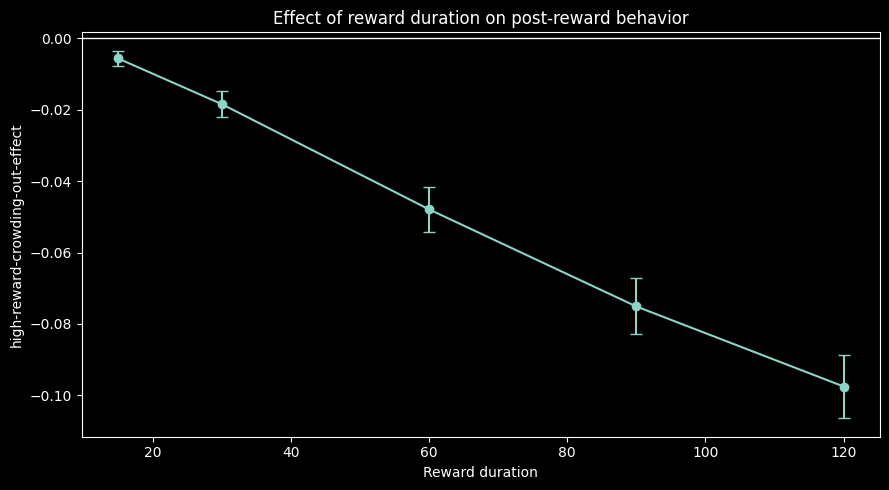

,reward-duration,mean,std,count,se,ci95
0,15,-0.005593,0.025518,540,0.001098,0.002152
1,30,-0.018384,0.044066,540,0.001896,0.003717
2,60,-0.047893,0.074057,540,0.003187,0.006246
3,90,-0.075108,0.092947,540,0.004000,0.007840
4,120,-0.097535,0.105780,540,0.004552,0.008922


In [48]:
duration_summary = (
    clean_df.groupby("reward-duration")[PRIMARY_TARGET]
    .agg(["mean", "std", "count"])
    .reset_index()
)

duration_summary["se"] = duration_summary["std"] / np.sqrt(duration_summary["count"])
duration_summary["ci95"] = 1.96 * duration_summary["se"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    duration_summary["reward-duration"],
    duration_summary["mean"],
    yerr=duration_summary["ci95"],
    marker="o",
    capsize=4,
)
ax.axhline(0, linewidth=1)
ax.set_title("Effect of reward duration on post-reward behavior")
ax.set_xlabel("Reward duration")
ax.set_ylabel(PRIMARY_TARGET)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "main_effect_reward_duration.png", dpi=200)
plt.show()

duration_summary

## Головні ефекти всіх параметрів

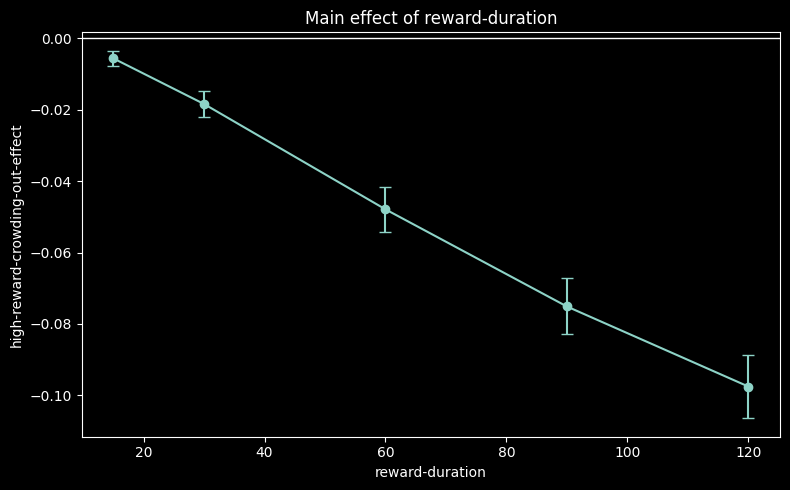

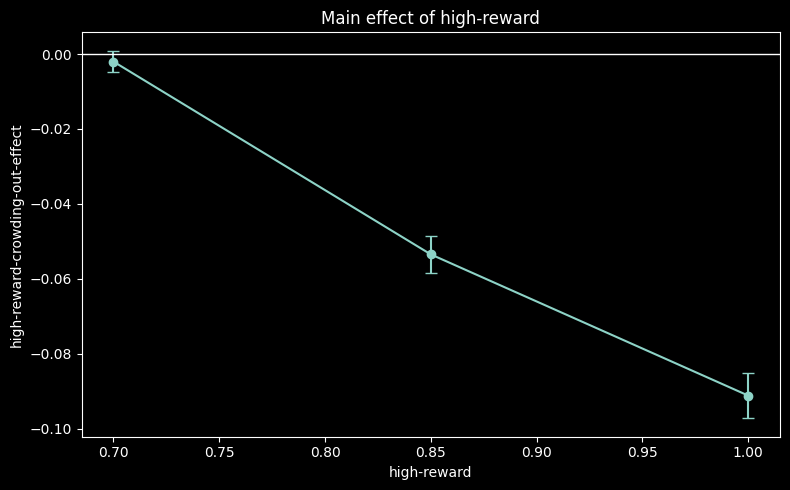

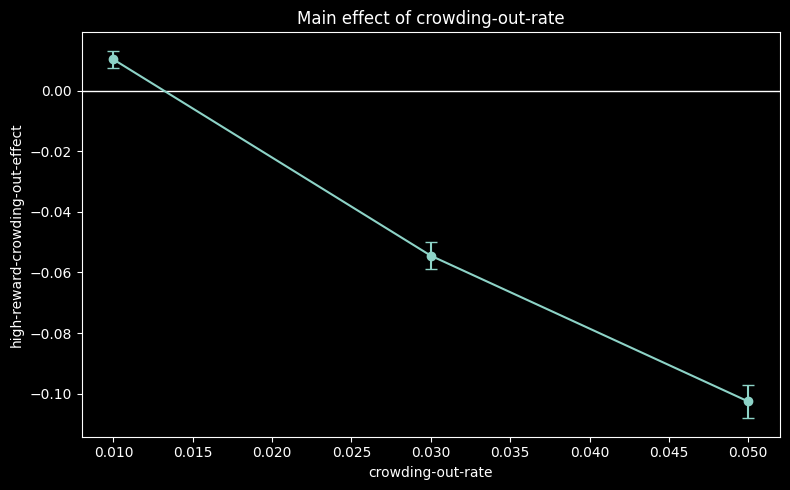

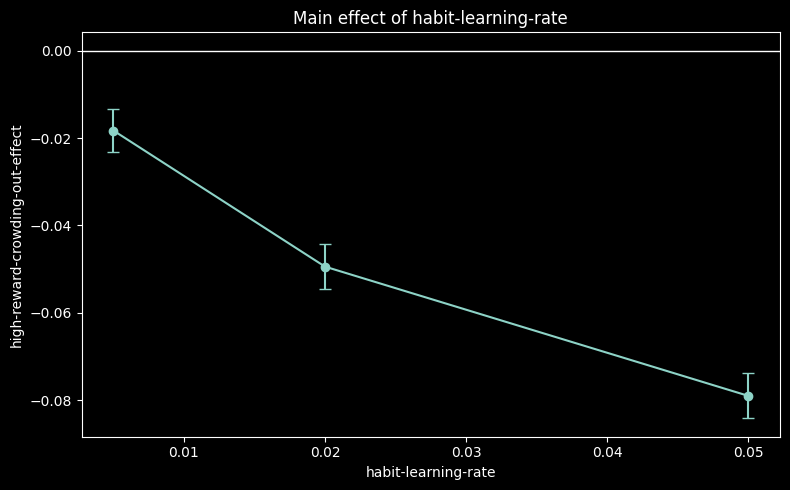

In [49]:
def main_effect_table(data, parameter, target):
    result = (
        data.groupby(parameter)[target]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    result["se"] = result["std"] / np.sqrt(result["count"])
    result["ci95"] = 1.96 * result["se"]
    return result


def plot_main_effect(data, parameter, target):
    result = main_effect_table(data, parameter, target)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(
        result[parameter],
        result["mean"],
        yerr=result["ci95"],
        marker="o",
        capsize=4,
    )
    ax.axhline(0, linewidth=1)
    ax.set_title(f"Main effect of {parameter}")
    ax.set_xlabel(parameter)
    ax.set_ylabel(target)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"main_effect_{parameter}.png", dpi=200)
    plt.show()

    return result


main_effect_results = {
    parameter: plot_main_effect(clean_df, parameter, PRIMARY_TARGET)
    for parameter in PARAMETERS
}

## Порівняння short-term uptake та withdrawal persistence

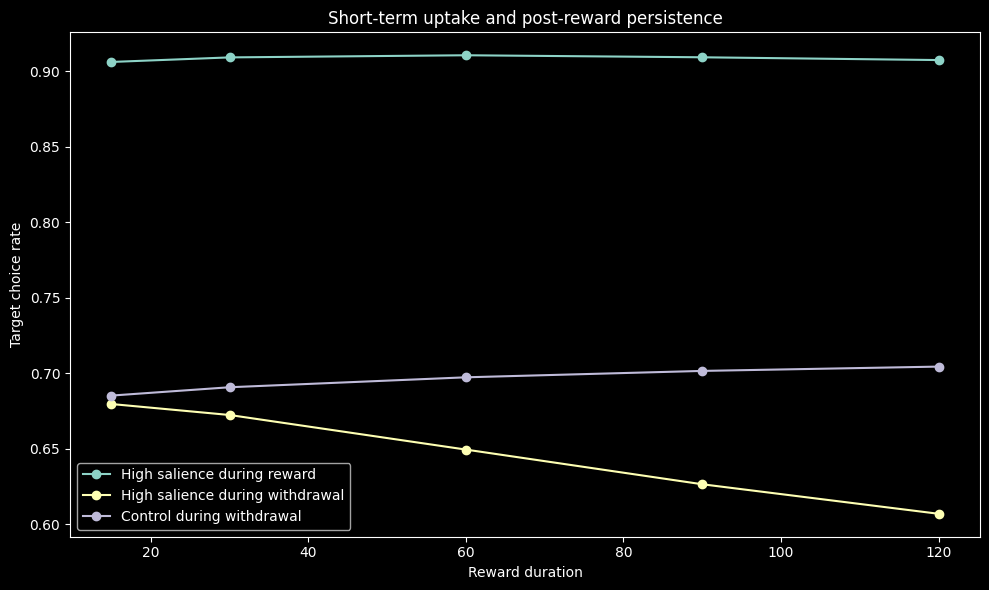

,reward-duration,high_reward_phase_rate,high_withdrawal_rate,low_reward_phase_rate,low_withdrawal_rate,control_withdrawal_rate
0,15,0.906244,0.679588,0.779377,0.702366,0.685181
1,30,0.909265,0.672316,0.792426,0.722047,0.690700
2,60,0.910680,0.649393,0.808740,0.749505,0.697286
3,90,0.909338,0.626416,0.821403,0.771112,0.701524
4,120,0.907494,0.606849,0.831624,0.789946,0.704383


In [50]:
comparison_rows = []

for duration in sorted(clean_df["reward-duration"].unique()):
    subset = clean_df[clean_df["reward-duration"] == duration]

    comparison_rows.append({
        "reward-duration": duration,
        "high_reward_phase_rate": subset[
            'choice-rate "high-salience" "reward"'
        ].mean(),
        "high_withdrawal_rate": subset[
            'choice-rate "high-salience" "withdrawal"'
        ].mean(),
        "low_reward_phase_rate": subset[
            'choice-rate "low-salience" "reward"'
        ].mean(),
        "low_withdrawal_rate": subset[
            'choice-rate "low-salience" "withdrawal"'
        ].mean(),
        "control_withdrawal_rate": subset[
            'choice-rate "control" "withdrawal"'
        ].mean(),
    })

duration_behavior_df = pd.DataFrame(comparison_rows)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    duration_behavior_df["reward-duration"],
    duration_behavior_df["high_reward_phase_rate"],
    marker="o",
    label="High salience during reward",
)
ax.plot(
    duration_behavior_df["reward-duration"],
    duration_behavior_df["high_withdrawal_rate"],
    marker="o",
    label="High salience during withdrawal",
)
ax.plot(
    duration_behavior_df["reward-duration"],
    duration_behavior_df["control_withdrawal_rate"],
    marker="o",
    label="Control during withdrawal",
)

ax.set_title("Short-term uptake and post-reward persistence")
ax.set_xlabel("Reward duration")
ax.set_ylabel("Target choice rate")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "uptake_vs_persistence_by_duration.png", dpi=200)
plt.show()

duration_behavior_df

## Retention ratio за тривалістю

Якщо готові reporters не були додані в NetLogo, retention ratio обчислюється в Python.

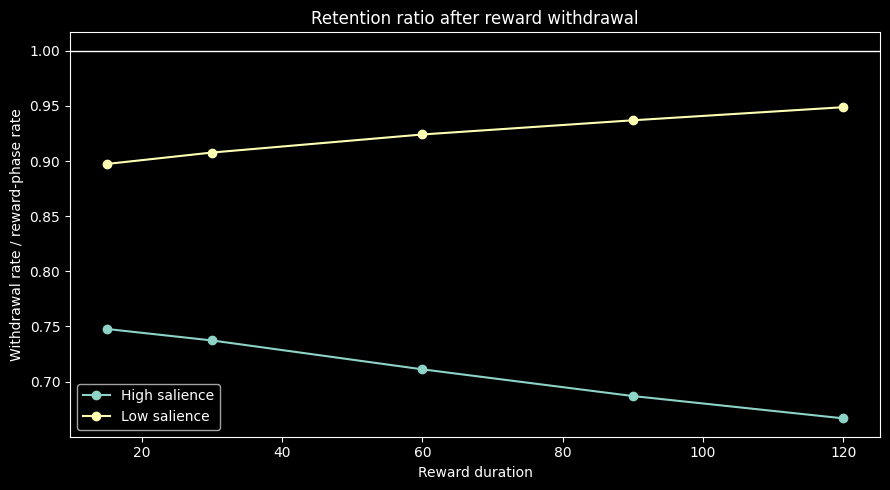

,reward-duration,computed-high-retention-ratio,computed-low-retention-ratio
0,15,0.747704,0.897341
1,30,0.737317,0.907684
2,60,0.711129,0.924062
3,90,0.686916,0.936922
4,120,0.666700,0.948790


In [51]:
clean_df["computed-high-retention-ratio"] = np.where(
    clean_df['choice-rate "high-salience" "reward"'] != 0,
    clean_df['choice-rate "high-salience" "withdrawal"']
    / clean_df['choice-rate "high-salience" "reward"'],
    np.nan,
)

clean_df["computed-low-retention-ratio"] = np.where(
    clean_df['choice-rate "low-salience" "reward"'] != 0,
    clean_df['choice-rate "low-salience" "withdrawal"']
    / clean_df['choice-rate "low-salience" "reward"'],
    np.nan,
)

retention_summary = (
    clean_df.groupby("reward-duration")[
        ["computed-high-retention-ratio", "computed-low-retention-ratio"]
    ]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    retention_summary["reward-duration"],
    retention_summary["computed-high-retention-ratio"],
    marker="o",
    label="High salience",
)
ax.plot(
    retention_summary["reward-duration"],
    retention_summary["computed-low-retention-ratio"],
    marker="o",
    label="Low salience",
)
ax.axhline(1, linewidth=1)
ax.set_title("Retention ratio after reward withdrawal")
ax.set_xlabel("Reward duration")
ax.set_ylabel("Withdrawal rate / reward-phase rate")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "retention_ratio_by_duration.png", dpi=200)
plt.show()

retention_summary

## Зміна внутрішньої мотивації та сили звички

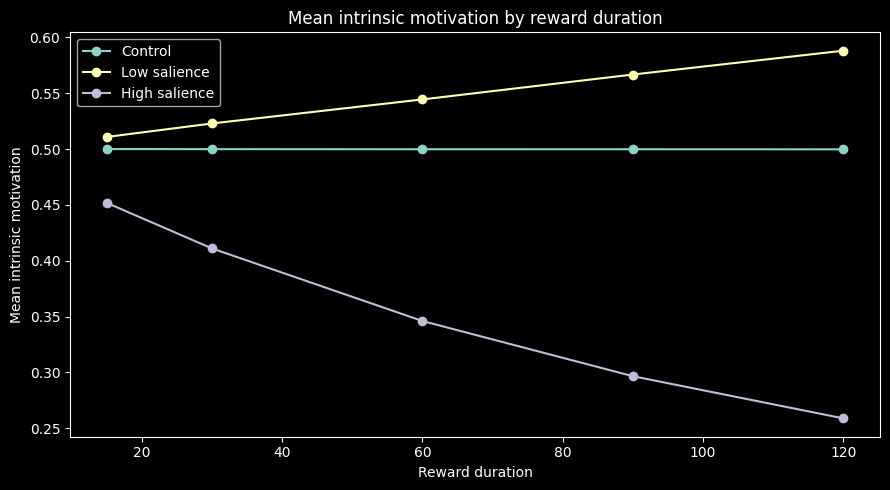

In [52]:
mechanism_summary = (
    clean_df.groupby("reward-duration")
    .agg(
        high_intrinsic=(
            'mean-intrinsic-motivation "high-salience"',
            "mean",
        ),
        low_intrinsic=(
            'mean-intrinsic-motivation "low-salience"',
            "mean",
        ),
        control_intrinsic=(
            'mean-intrinsic-motivation "control"',
            "mean",
        ),
        high_habit=(
            'mean-habit "high-salience"',
            "mean",
        ),
        low_habit=(
            'mean-habit "low-salience"',
            "mean",
        ),
        control_habit=(
            'mean-habit "control"',
            "mean",
        ),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    mechanism_summary["reward-duration"],
    mechanism_summary["control_intrinsic"],
    marker="o",
    label="Control",
)
ax.plot(
    mechanism_summary["reward-duration"],
    mechanism_summary["low_intrinsic"],
    marker="o",
    label="Low salience",
)
ax.plot(
    mechanism_summary["reward-duration"],
    mechanism_summary["high_intrinsic"],
    marker="o",
    label="High salience",
)
ax.set_title("Mean intrinsic motivation by reward duration")
ax.set_xlabel("Reward duration")
ax.set_ylabel("Mean intrinsic motivation")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "intrinsic_motivation_by_duration.png", dpi=200)
plt.show()

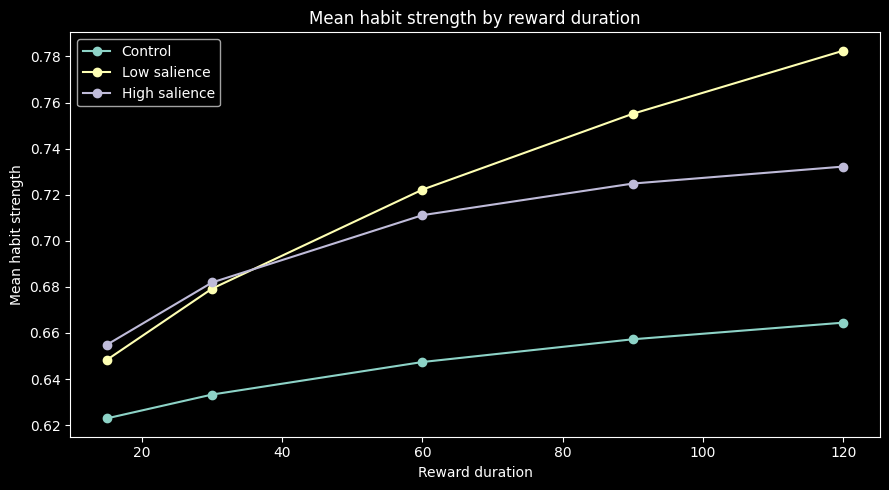

,reward-duration,high_intrinsic,low_intrinsic,control_intrinsic,high_habit,low_habit,control_habit
0,15,0.451757,0.510895,0.500022,0.654903,0.648342,0.622927
1,30,0.411003,0.522970,0.499945,0.681914,0.679247,0.633259
2,60,0.346005,0.544505,0.499859,0.711123,0.722209,0.647380
3,90,0.296572,0.566795,0.499873,0.724839,0.755133,0.657246
4,120,0.258803,0.588140,0.499787,0.732205,0.782499,0.664456


In [53]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    mechanism_summary["reward-duration"],
    mechanism_summary["control_habit"],
    marker="o",
    label="Control",
)
ax.plot(
    mechanism_summary["reward-duration"],
    mechanism_summary["low_habit"],
    marker="o",
    label="Low salience",
)
ax.plot(
    mechanism_summary["reward-duration"],
    mechanism_summary["high_habit"],
    marker="o",
    label="High salience",
)
ax.set_title("Mean habit strength by reward duration")
ax.set_xlabel("Reward duration")
ax.set_ylabel("Mean habit strength")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "habit_strength_by_duration.png", dpi=200)
plt.show()

mechanism_summary

## Heatmap: reward duration × crowding-out rate

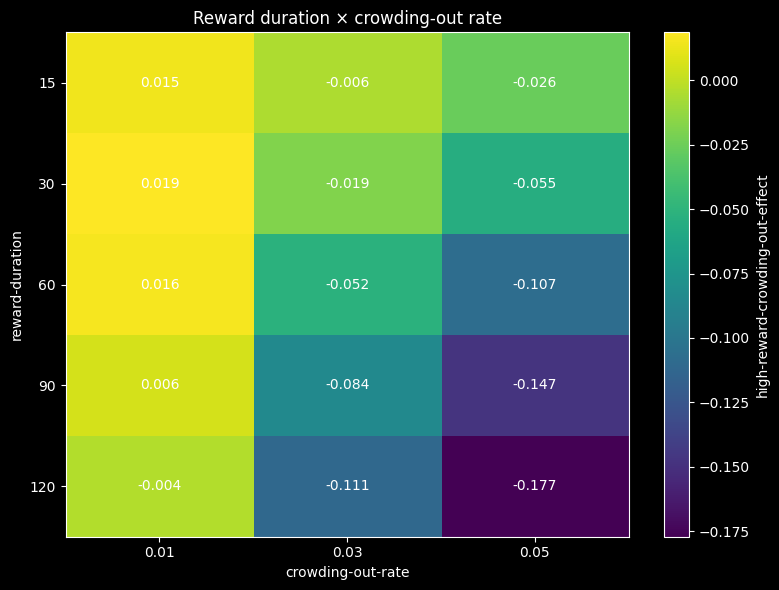

crowding-out-rate,0.01,0.03,0.05
reward-duration,,,
15,0.014749,-0.005735,-0.025792
30,0.018649,-0.018770,-0.055030
60,0.016058,-0.052278,-0.107460
90,0.006266,-0.084182,-0.147410
120,-0.004080,-0.111338,-0.177186


In [54]:
pivot_duration_crowding = clean_df.pivot_table(
    values=PRIMARY_TARGET,
    index="reward-duration",
    columns="crowding-out-rate",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(pivot_duration_crowding.values, aspect="auto")

ax.set_xticks(range(len(pivot_duration_crowding.columns)))
ax.set_xticklabels(pivot_duration_crowding.columns)
ax.set_yticks(range(len(pivot_duration_crowding.index)))
ax.set_yticklabels(pivot_duration_crowding.index)

ax.set_xlabel("crowding-out-rate")
ax.set_ylabel("reward-duration")
ax.set_title("Reward duration × crowding-out rate")

for row in range(pivot_duration_crowding.shape[0]):
    for column in range(pivot_duration_crowding.shape[1]):
        value = pivot_duration_crowding.iloc[row, column]
        ax.text(column, row, f"{value:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label=PRIMARY_TARGET)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_duration_vs_crowding.png", dpi=200)
plt.show()

pivot_duration_crowding

## Heatmap: reward duration × habit learning

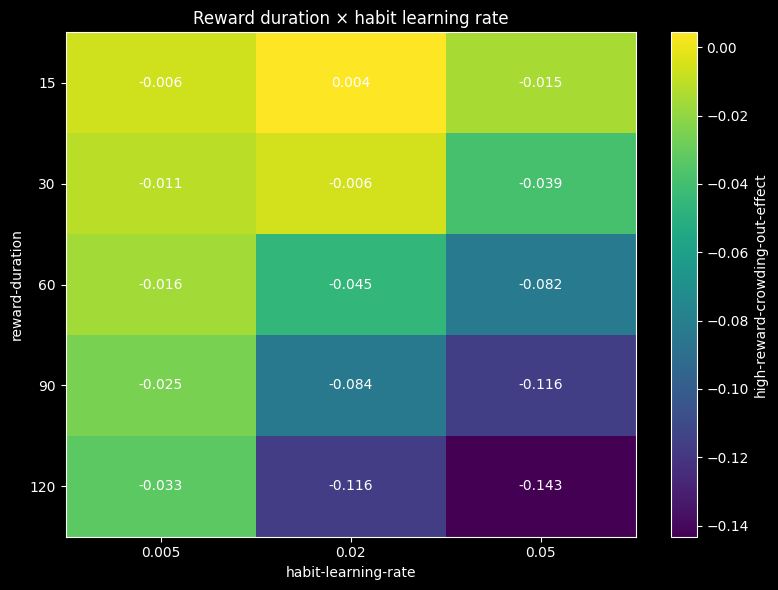

habit-learning-rate,0.005,0.020,0.050
reward-duration,,,
15,-0.006443,0.004401,-0.014735
30,-0.010670,-0.005956,-0.038526
60,-0.015903,-0.045349,-0.082428
90,-0.025436,-0.083836,-0.116053
120,-0.032925,-0.116394,-0.143285


In [55]:
pivot_duration_habit = clean_df.pivot_table(
    values=PRIMARY_TARGET,
    index="reward-duration",
    columns="habit-learning-rate",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(pivot_duration_habit.values, aspect="auto")

ax.set_xticks(range(len(pivot_duration_habit.columns)))
ax.set_xticklabels(pivot_duration_habit.columns)
ax.set_yticks(range(len(pivot_duration_habit.index)))
ax.set_yticklabels(pivot_duration_habit.index)

ax.set_xlabel("habit-learning-rate")
ax.set_ylabel("reward-duration")
ax.set_title("Reward duration × habit learning rate")

for row in range(pivot_duration_habit.shape[0]):
    for column in range(pivot_duration_habit.shape[1]):
        value = pivot_duration_habit.iloc[row, column]
        ax.text(column, row, f"{value:.3f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label=PRIMARY_TARGET)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_duration_vs_habit.png", dpi=200)
plt.show()

pivot_duration_habit

## Interaction plot: duration × crowding-out

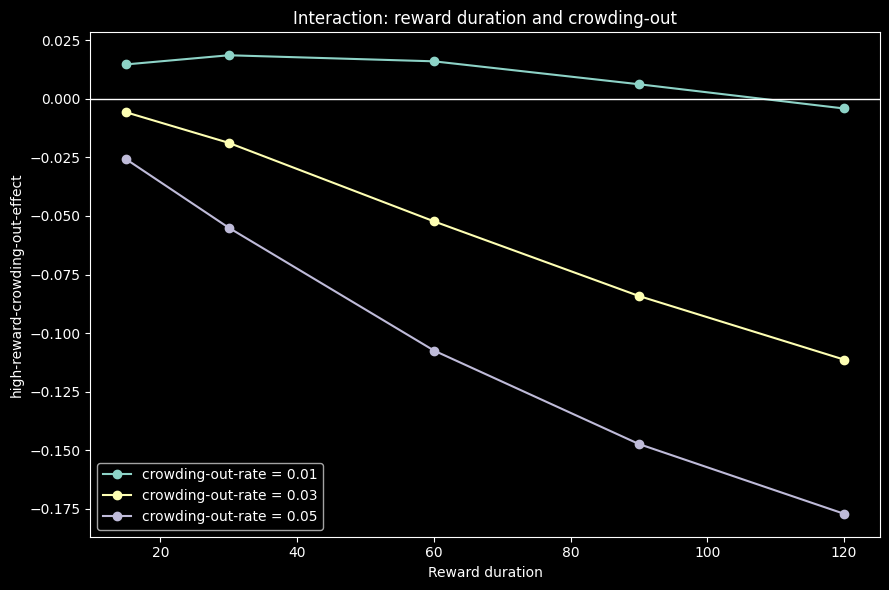

In [56]:
interaction_duration_crowding = (
    clean_df.groupby(["reward-duration", "crowding-out-rate"])[PRIMARY_TARGET]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

for rate in sorted(
    interaction_duration_crowding["crowding-out-rate"].unique()
):
    subset = interaction_duration_crowding[
        interaction_duration_crowding["crowding-out-rate"] == rate
    ]
    ax.plot(
        subset["reward-duration"],
        subset[PRIMARY_TARGET],
        marker="o",
        label=f"crowding-out-rate = {rate}",
    )

ax.axhline(0, linewidth=1)
ax.set_title("Interaction: reward duration and crowding-out")
ax.set_xlabel("Reward duration")
ax.set_ylabel(PRIMARY_TARGET)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "interaction_duration_crowding.png", dpi=200)
plt.show()

## Interaction plot: duration × habit learning

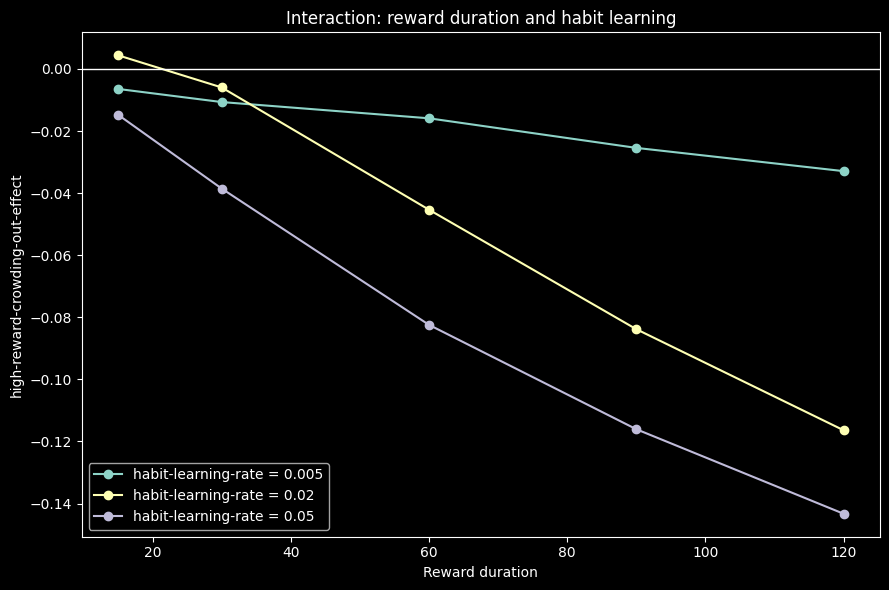

In [57]:
interaction_duration_habit = (
    clean_df.groupby(["reward-duration", "habit-learning-rate"])[PRIMARY_TARGET]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

for rate in sorted(
    interaction_duration_habit["habit-learning-rate"].unique()
):
    subset = interaction_duration_habit[
        interaction_duration_habit["habit-learning-rate"] == rate
    ]
    ax.plot(
        subset["reward-duration"],
        subset[PRIMARY_TARGET],
        marker="o",
        label=f"habit-learning-rate = {rate}",
    )

ax.axhline(0, linewidth=1)
ax.set_title("Interaction: reward duration and habit learning")
ax.set_xlabel("Reward duration")
ax.set_ylabel(PRIMARY_TARGET)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "interaction_duration_habit.png", dpi=200)
plt.show()

## Factorial ANOVA

Параметри трактуються як категоріальні фактори. Модель включає головні ефекти та всі двофакторні взаємодії.

In [58]:
anova_df = clean_df.rename(columns={
    "reward-duration": "reward_duration",
    "high-reward": "high_reward",
    "crowding-out-rate": "crowding_out_rate",
    "habit-learning-rate": "habit_learning_rate",
    PRIMARY_TARGET: "crowding_effect",
})

formula = (
    "crowding_effect ~ "
    "C(reward_duration) + "
    "C(high_reward) + "
    "C(crowding_out_rate) + "
    "C(habit_learning_rate) + "
    "C(reward_duration):C(high_reward) + "
    "C(reward_duration):C(crowding_out_rate) + "
    "C(reward_duration):C(habit_learning_rate) + "
    "C(high_reward):C(crowding_out_rate) + "
    "C(high_reward):C(habit_learning_rate) + "
    "C(crowding_out_rate):C(habit_learning_rate)"
)

anova_model = smf.ols(formula, data=anova_df).fit()
anova_table = anova_lm(anova_model, typ=2)

anova_table["eta_squared"] = (
    anova_table["sum_sq"] / anova_table["sum_sq"].sum()
)

anova_table = anova_table.sort_values("eta_squared", ascending=False)
anova_table.to_csv(OUTPUT_DIR / "factorial_anova_second_experiment.csv")

anova_table

,sum_sq,df,F,PR(>F),eta_squared
C(crowding_out_rate),5.778022,2.0,20522.457507,0.000000e+00,0.317374
C(high_reward),3.608813,2.0,12817.831153,0.000000e+00,0.198224
C(reward_duration),3.164413,4.0,5619.702076,0.000000e+00,0.173814
C(habit_learning_rate),1.660045,2.0,5896.171989,0.000000e+00,0.091183
C(reward_duration):C(crowding_out_rate),1.132893,8.0,1005.956422,0.000000e+00,0.062227
C(reward_duration):C(habit_learning_rate),0.836477,8.0,742.752818,0.000000e+00,0.045946
C(reward_duration):C(high_reward),0.779117,8.0,691.819687,0.000000e+00,0.042795
C(high_reward):C(crowding_out_rate),0.772151,4.0,1371.267807,0.000000e+00,0.042413
Residual,0.373471,2653.0,NaN,NaN,0.020514
C(crowding_out_rate):C(habit_learning_rate),0.098244,4.0,174.472616,8.041156e-133,0.005396


## Діагностика ANOVA

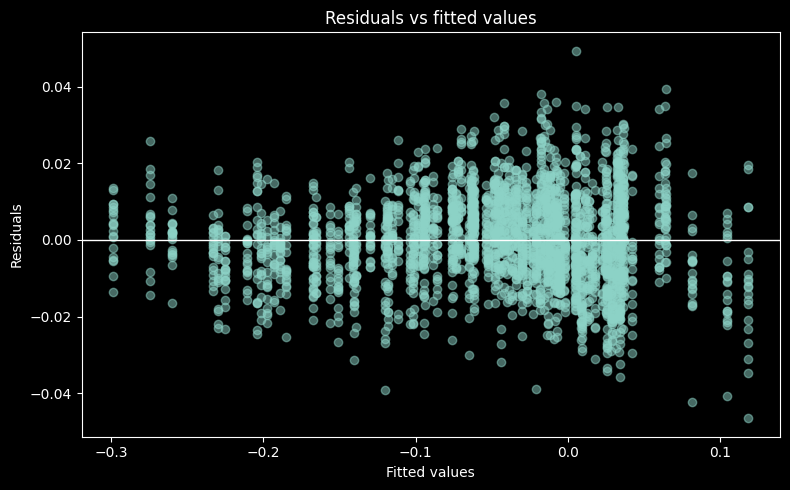

In [59]:
residuals = anova_model.resid
fitted = anova_model.fittedvalues

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted, residuals, alpha=0.5)
ax.axhline(0, linewidth=1)
ax.set_title("Residuals vs fitted values")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "anova_residuals_vs_fitted.png", dpi=200)
plt.show()

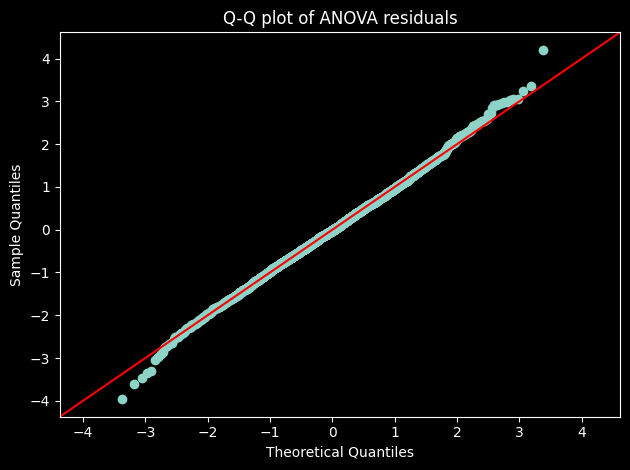

In [60]:
fig = sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q plot of ANOVA residuals")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "anova_residuals_qq.png", dpi=200)
plt.show()

## Random Forest

In [61]:
X = clean_df[PARAMETERS].copy()
y = clean_df[PRIMARY_TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=1,
)

rf.fit(X_train, y_train)
predictions = rf.predict(X_test)

print("R²:", round(r2_score(y_test, predictions), 4))
print("MAE:", round(mean_absolute_error(y_test, predictions), 4))

R²: 0.9845
MAE: 0.0081


## Permutation importance

In [62]:
permutation = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2",
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "parameter": PARAMETERS,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.to_csv(
    OUTPUT_DIR / "permutation_importance_second_experiment.csv",
    index=False,
)

importance_df

,parameter,importance_mean,importance_std
2,crowding-out-rate,0.867980,0.053882
0,reward-duration,0.694186,0.031164
1,high-reward,0.566545,0.035602
3,habit-learning-rate,0.290257,0.017020


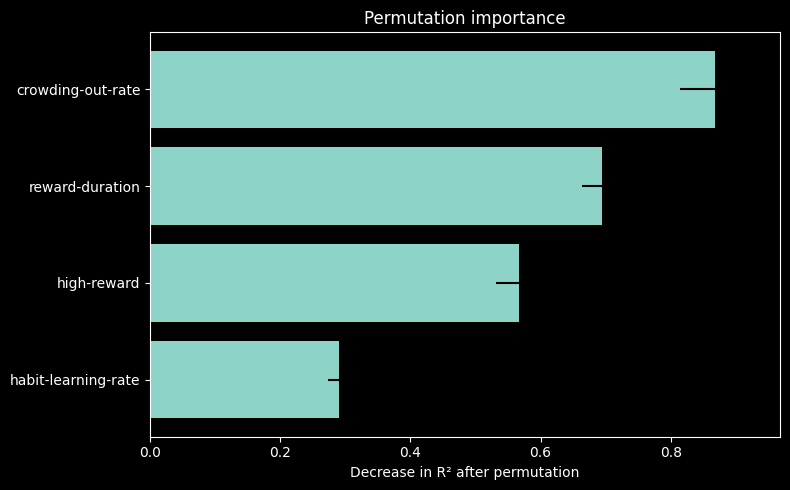

In [63]:
ordered = importance_df.sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    ordered["parameter"],
    ordered["importance_mean"],
    xerr=ordered["importance_std"],
)
ax.set_title("Permutation importance")
ax.set_xlabel("Decrease in R² after permutation")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "permutation_importance.png", dpi=200)
plt.show()

## Partial dependence

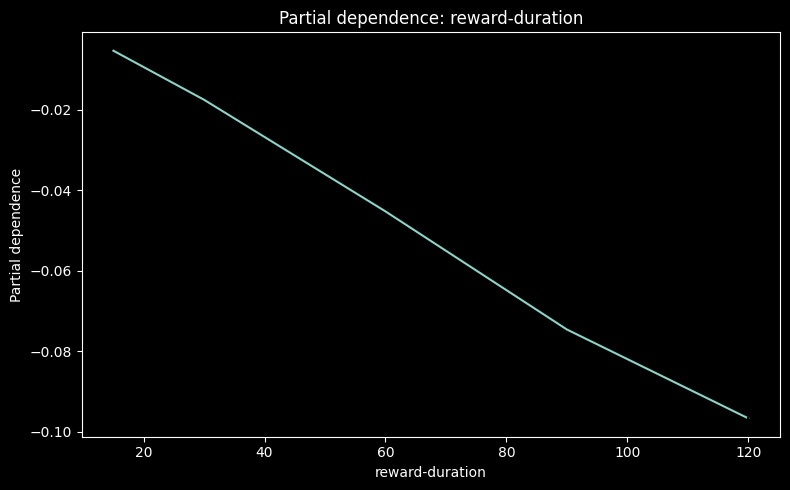

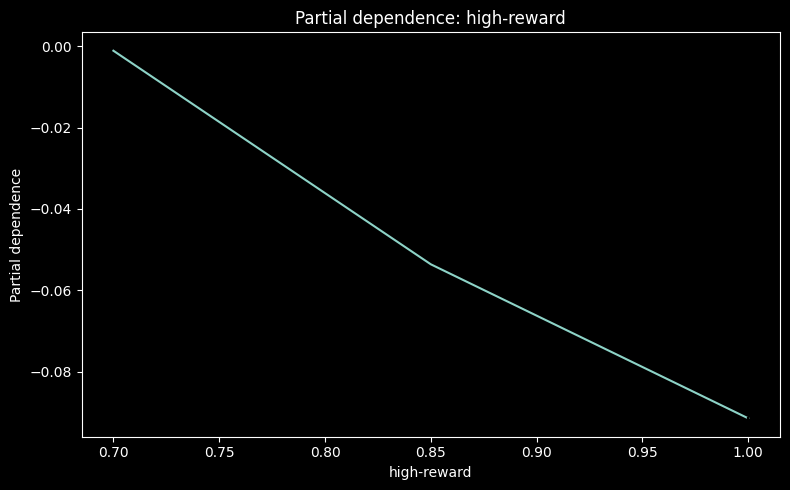

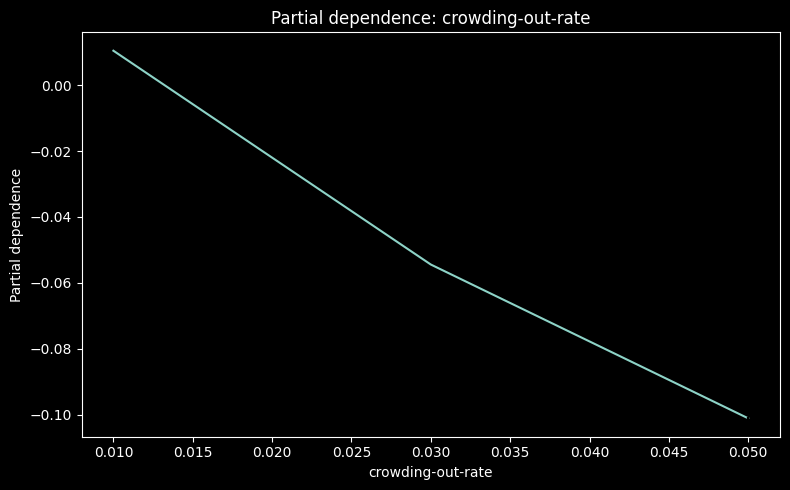

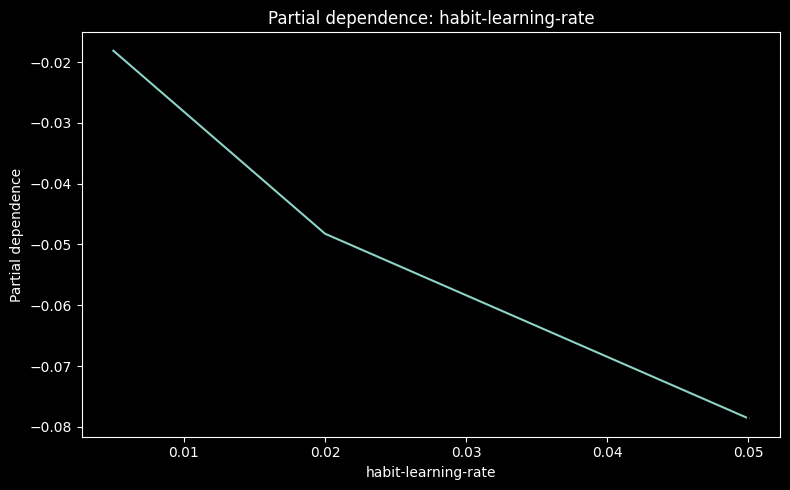

In [64]:
for parameter in PARAMETERS:
    fig, ax = plt.subplots(figsize=(8, 5))
    PartialDependenceDisplay.from_estimator(
        rf,
        X_train,
        [parameter],
        ax=ax,
    )
    ax.set_title(f"Partial dependence: {parameter}")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"partial_dependence_{parameter}.png",
        dpi=200,
    )
    plt.show()

## Підсумок сценаріїв

In [65]:
scenario_summary = (
    clean_df.groupby(PARAMETERS)
    .agg(
        mean_crowding_effect=(PRIMARY_TARGET, "mean"),
        std_crowding_effect=(PRIMARY_TARGET, "std"),
        mean_low_persistence=(SECONDARY_TARGET, "mean"),
        mean_high_retention=(
            "computed-high-retention-ratio",
            "mean",
        ),
        mean_low_retention=(
            "computed-low-retention-ratio",
            "mean",
        ),
        crowding_probability=(
            PRIMARY_TARGET,
            lambda values: (values < 0).mean(),
        ),
        runs=(PRIMARY_TARGET, "size"),
    )
    .reset_index()
)

scenario_summary.to_csv(
    OUTPUT_DIR / "scenario_summary_second_experiment.csv",
    index=False,
)

print("Сценарії з найсильнішим crowding-out:")
display(
    scenario_summary
    .sort_values("mean_crowding_effect")
    .head(10)
)

print("Сценарії з найкращою persistence:")
display(
    scenario_summary
    .sort_values("mean_crowding_effect", ascending=False)
    .head(10)
)

Сценарії з найсильнішим crowding-out:


,reward-duration,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,crowding_probability,runs
134,120,1.00,0.05,0.050,-0.295896,0.007400,0.046239,0.543896,0.949314,1.0,20
133,120,1.00,0.05,0.020,-0.269937,0.009852,0.077744,0.531575,0.973152,1.0,20
107,90,1.00,0.05,0.050,-0.259445,0.005786,0.038793,0.576140,0.944340,1.0,20
125,120,0.85,0.05,0.050,-0.236222,0.005470,0.046656,0.612894,0.948385,1.0,20
106,90,1.00,0.05,0.020,-0.234134,0.011155,0.067213,0.561667,0.967362,1.0,20
131,120,1.00,0.03,0.050,-0.233108,0.006344,0.046830,0.601745,0.949565,1.0,20
124,120,0.85,0.05,0.020,-0.214709,0.006659,0.072536,0.603472,0.972346,1.0,20
80,60,1.00,0.05,0.050,-0.205416,0.008774,0.024820,0.628762,0.937328,1.0,20
130,120,1.00,0.03,0.020,-0.204634,0.009526,0.077749,0.592647,0.970939,1.0,20
132,120,1.00,0.05,0.005,-0.203404,0.014701,0.136514,0.410483,0.923775,1.0,20


Сценарії з найкращою persistence:


,reward-duration,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,crowding_probability,runs
108,120,0.70,0.01,0.005,0.106515,0.016996,0.133657,0.767320,0.925216,0.0,20
81,90,0.70,0.01,0.005,0.093234,0.012033,0.103262,0.755207,0.898885,0.0,20
117,120,0.85,0.01,0.005,0.073692,0.009122,0.134513,0.707652,0.926795,0.0,20
90,90,0.85,0.01,0.005,0.073470,0.011956,0.107829,0.707206,0.901722,0.0,20
54,60,0.70,0.01,0.005,0.073138,0.011814,0.075958,0.736701,0.872551,0.0,20
63,60,0.85,0.01,0.005,0.063876,0.011753,0.075179,0.696100,0.872092,0.0,20
126,120,1.00,0.01,0.005,0.048253,0.007338,0.135575,0.659730,0.925654,0.0,20
72,60,1.00,0.01,0.005,0.047837,0.011435,0.073195,0.660991,0.870283,0.0,20
99,90,1.00,0.01,0.005,0.045846,0.008464,0.103011,0.660316,0.898204,0.0,20
27,30,0.70,0.01,0.005,0.040825,0.012326,0.036761,0.710219,0.838723,0.0,20


## Стабільні режими crowding-out і persistence

In [66]:
stable_crowding = (
    scenario_summary[
        (scenario_summary["mean_crowding_effect"] < 0)
        & (scenario_summary["crowding_probability"] >= 0.80)
    ]
    .sort_values(
        ["crowding_probability", "mean_crowding_effect"],
        ascending=[False, True],
    )
)

stable_persistence = (
    scenario_summary[
        (scenario_summary["mean_crowding_effect"] > 0)
        & (scenario_summary["crowding_probability"] <= 0.20)
    ]
    .sort_values(
        "mean_crowding_effect",
        ascending=False,
    )
)

print("Stable crowding-out scenarios:", len(stable_crowding))
display(stable_crowding.head(20))

print("Stable persistence scenarios:", len(stable_persistence))
display(stable_persistence.head(20))

Stable crowding-out scenarios: 87


,reward-duration,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,crowding_probability,runs
134,120,1.00,0.05,0.050,-0.295896,0.007400,0.046239,0.543896,0.949314,1.0,20
133,120,1.00,0.05,0.020,-0.269937,0.009852,0.077744,0.531575,0.973152,1.0,20
107,90,1.00,0.05,0.050,-0.259445,0.005786,0.038793,0.576140,0.944340,1.0,20
125,120,0.85,0.05,0.050,-0.236222,0.005470,0.046656,0.612894,0.948385,1.0,20
106,90,1.00,0.05,0.020,-0.234134,0.011155,0.067213,0.561667,0.967362,1.0,20
131,120,1.00,0.03,0.050,-0.233108,0.006344,0.046830,0.601745,0.949565,1.0,20
124,120,0.85,0.05,0.020,-0.214709,0.006659,0.072536,0.603472,0.972346,1.0,20
80,60,1.00,0.05,0.050,-0.205416,0.008774,0.024820,0.628762,0.937328,1.0,20
130,120,1.00,0.03,0.020,-0.204634,0.009526,0.077749,0.592647,0.970939,1.0,20
132,120,1.00,0.05,0.005,-0.203404,0.014701,0.136514,0.410483,0.923775,1.0,20


Stable persistence scenarios: 33


,reward-duration,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,crowding_probability,runs
108,120,0.70,0.01,0.005,0.106515,0.016996,0.133657,0.767320,0.925216,0.0,20
81,90,0.70,0.01,0.005,0.093234,0.012033,0.103262,0.755207,0.898885,0.0,20
117,120,0.85,0.01,0.005,0.073692,0.009122,0.134513,0.707652,0.926795,0.0,20
90,90,0.85,0.01,0.005,0.073470,0.011956,0.107829,0.707206,0.901722,0.0,20
54,60,0.70,0.01,0.005,0.073138,0.011814,0.075958,0.736701,0.872551,0.0,20
63,60,0.85,0.01,0.005,0.063876,0.011753,0.075179,0.696100,0.872092,0.0,20
126,120,1.00,0.01,0.005,0.048253,0.007338,0.135575,0.659730,0.925654,0.0,20
72,60,1.00,0.01,0.005,0.047837,0.011435,0.073195,0.660991,0.870283,0.0,20
99,90,1.00,0.01,0.005,0.045846,0.008464,0.103011,0.660316,0.898204,0.0,20
27,30,0.70,0.01,0.005,0.040825,0.012326,0.036761,0.710219,0.838723,0.0,20


## Пошук найкращої тривалості

Умовний composite score винагороджує:

- позитивний post-reward effect;
- високий retention ratio;
- низьку ймовірність crowding-out.

Це допоміжний показник, а не остаточна наукова метрика.

In [67]:
scenario_summary["composite_score"] = (
    scenario_summary["mean_crowding_effect"]
    + 0.25 * scenario_summary["mean_high_retention"]
    - 0.25 * scenario_summary["crowding_probability"]
)

best_duration_scenarios = (
    scenario_summary
    .sort_values("composite_score", ascending=False)
    .head(20)
)

best_duration_scenarios

,reward-duration,high-reward,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_retention,mean_low_retention,crowding_probability,runs,composite_score
108,120,0.70,0.01,0.005,0.106515,0.016996,0.133657,0.767320,0.925216,0.00,20,0.298345
81,90,0.70,0.01,0.005,0.093234,0.012033,0.103262,0.755207,0.898885,0.00,20,0.282036
54,60,0.70,0.01,0.005,0.073138,0.011814,0.075958,0.736701,0.872551,0.00,20,0.257313
117,120,0.85,0.01,0.005,0.073692,0.009122,0.134513,0.707652,0.926795,0.00,20,0.250605
90,90,0.85,0.01,0.005,0.073470,0.011956,0.107829,0.707206,0.901722,0.00,20,0.250271
28,30,0.70,0.01,0.020,0.032489,0.013477,0.035039,0.840975,0.948864,0.00,20,0.242733
55,60,0.70,0.01,0.020,0.031250,0.008875,0.053830,0.845062,0.959514,0.00,20,0.242516
63,60,0.85,0.01,0.005,0.063876,0.011753,0.075179,0.696100,0.872092,0.00,20,0.237901
37,30,0.85,0.01,0.020,0.031101,0.009410,0.039607,0.813689,0.945218,0.00,20,0.234523
1,15,0.70,0.01,0.020,0.025139,0.011680,0.020191,0.826850,0.931038,0.00,20,0.231851


## Коротке автоматичне резюме

In [68]:
most_important_parameter = importance_df.iloc[0]["parameter"]
largest_anova_effect = anova_table.index[0]

duration_means = (
    clean_df.groupby("reward-duration")[PRIMARY_TARGET]
    .mean()
    .sort_values(ascending=False)
)

print("Середній high-reward crowding-out effect:", round(clean_df[PRIMARY_TARGET].mean(), 4))
print("Частка запусків із crowding-out:", f"{crowding_share:.1%}")
print("Найважливіший параметр за permutation importance:", most_important_parameter)
print("Найбільший ефект за ANOVA eta²:", largest_anova_effect)
print("Тривалість із найкращим середнім post-reward effect:", duration_means.index[0])
print("Тривалість із найгіршим середнім post-reward effect:", duration_means.index[-1])

Середній high-reward crowding-out effect: -0.0489
Частка запусків із crowding-out: 69.8%
Найважливіший параметр за permutation importance: crowding-out-rate
Найбільший ефект за ANOVA eta²: C(crowding_out_rate)
Тривалість із найкращим середнім post-reward effect: 15
Тривалість із найгіршим середнім post-reward effect: 120


## Експорт очищених даних

In [69]:
clean_df.to_csv(
    OUTPUT_DIR / "clean_second_experiment_data.csv",
    index=False,
)

print("Результати збережено у:")
print(OUTPUT_DIR.resolve())

Результати збережено у:
/Users/igor/projects/phd/reward-habits-model/analysis_output_second_experiment
